In [7]:
# Basic Time Series Tinkering 001 #

In [8]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.datasets import get_rdataset
from statsmodels.graphics.tsaplots import (
    month_plot, quarter_plot
)
from statsmodels.graphics.tsaplots import (
    plot_acf, plot_pacf
)
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error
    , mean_absolute_percentage_error
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_style('darkgrid')
plt.style.use('seaborn-v0_8-darkgrid')

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Load the dataset
data = get_rdataset(
    "AirPassengers"
    , package="datasets"
).data

df = data.copy()

print(df.shape)
df.head(3)

(144, 2)


,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132


In [4]:
df.tail(3)

,time,value
141,1960.750000,461
142,1960.833333,390
143,1960.916667,432


In [5]:
# ALWAYS set the datetime as the Index when working w/ TS data!!!

df['Month'] = pd.date_range(
    start='1949-01'
    , periods=len(df)
    , freq='M')

df.set_index('Month', inplace=True)
df.rename(columns={'value': 'Passengers'}, inplace=True)

df.head(1)

,time,Passengers
Month,,
1949-01-31,1949.0,112


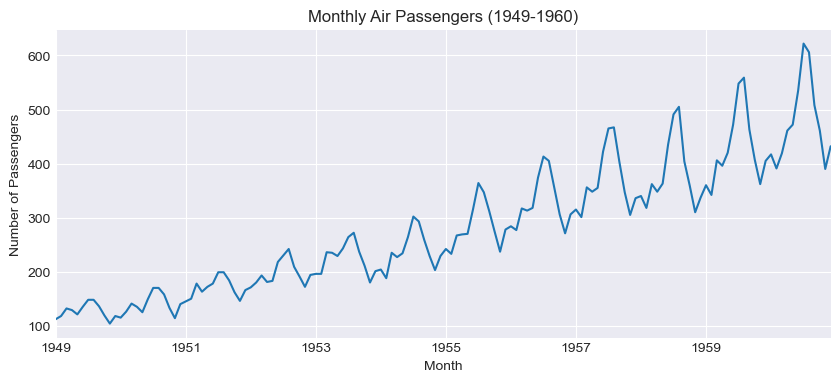

In [9]:
# Plot the time series

df['Passengers'].plot(
    title='Monthly Air Passengers (1949-1960)'
    , figsize=(10, 4)
)
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show();